● Fetch live cryptocurrency prices
● Analyze market trends
● Track top gainers and losers
● Visualize price changes
● Generate analytical reports
● Support multiple cryptocurrencies

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import requests

url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 20,
    "page": 1,
    "sparkline": False,
    "price_change_percentage": "24h"
}

response = requests.get(url, params=params)

data = response.json()

df = pd.DataFrame(data)

print(df[[
    "name",
    "symbol",
    "current_price",
    "market_cap",
    "total_volume",
    "price_change_percentage_24h"
]])

             name      symbol  current_price     market_cap  total_volume  \
0         Bitcoin         btc   63986.000000  1282979908525   32273196234   
1        Ethereum         eth    1802.960000   217430420569    9880765226   
2          Tether        usdt       0.999156   184199855204   50788364495   
3             BNB         bnb     585.200000    78861379134     594072343   
4            USDC        usdc       0.999890    73091337993   12843508547   
5             XRP         xrp       1.130000    70265603384    1470847303   
6          Solana         sol      82.140000    47773657365    2363958524   
7            TRON         trx       0.332141    31506741360     413378117   
8    Figure Heloc  figr_heloc       1.030000    20173762457      76368680   
9     Hyperliquid        hype      71.670000    15942368304     493556382   
10       Dogecoin        doge       0.075358    11677236919     655556454   
11           USDS        usds       0.999787    11001353646     210510257   

In [2]:
print("\nAverage Price")
print(df["current_price"].mean())

print("\nHighest Price")
print(df["current_price"].max())

print("\nLowest Price")
print(df["current_price"].min())

print("\nAverage 24h Change")
print(df["price_change_percentage_24h"].mean())


Average Price
3372.424593471499

Highest Price
63986.0

Lowest Price
0.01493443

Average 24h Change
0.2450334999999999


In [3]:
top_gainers = df.sort_values(
    by="price_change_percentage_24h",
    ascending=False
)

print(top_gainers[[
    "name",
    "current_price",
    "price_change_percentage_24h"
]].head(10))

           name  current_price  price_change_percentage_24h
14        Zcash     507.230000                     12.26036
18       Monero     333.170000                      3.41304
7          TRON       0.332141                      1.41710
9   Hyperliquid      71.670000                      0.87950
1      Ethereum    1802.960000                      0.58290
0       Bitcoin   63986.000000                      0.53734
6        Solana      82.140000                      0.30839
3           BNB     585.200000                      0.13405
11         USDS       0.999787                      0.01872
4          USDC       0.999890                      0.01098


In [4]:
top_losers = df.sort_values(
    by="price_change_percentage_24h"
)

print(top_losers[[
    "name",
    "current_price",
    "price_change_percentage_24h"
]].head(10))

             name  current_price  price_change_percentage_24h
16        Cardano       0.177535                     -3.84225
17        Stellar       0.193068                     -3.59898
5             XRP       1.130000                     -1.89220
10       Dogecoin       0.075358                     -1.85955
12           Rain       0.014934                     -1.02170
8    Figure Heloc       1.030000                     -1.01158
15  WhiteBIT Coin      56.800000                     -0.72536
19      Chainlink       8.010000                     -0.51704
13      LEO Token       9.360000                     -0.19028
2          Tether       0.999156                     -0.00277


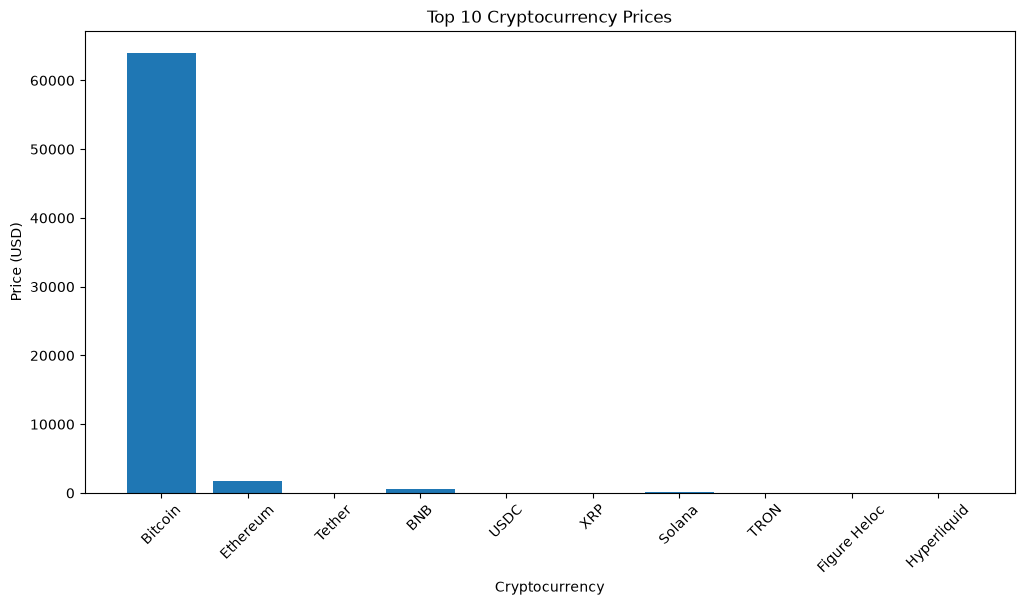

In [5]:
top10 = df.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10["name"], top10["current_price"])

plt.xticks(rotation=45)

plt.title("Top 10 Cryptocurrency Prices")

plt.xlabel("Cryptocurrency")

plt.ylabel("Price (USD)")

plt.show()

In [6]:
url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"

params = {
    "vs_currency": "usd",
    "days": 30
}

response = requests.get(url, params=params)

data = response.json()

prices = data["prices"]

history = pd.DataFrame(prices, columns=["Timestamp", "Price"])

print(history.head())

       Timestamp         Price
0  1780851671565  62019.381509
1  1780855214102  62139.104584
2  1780858828087  62065.134720
3  1780862403269  61277.739884
4  1780866030661  61896.185846


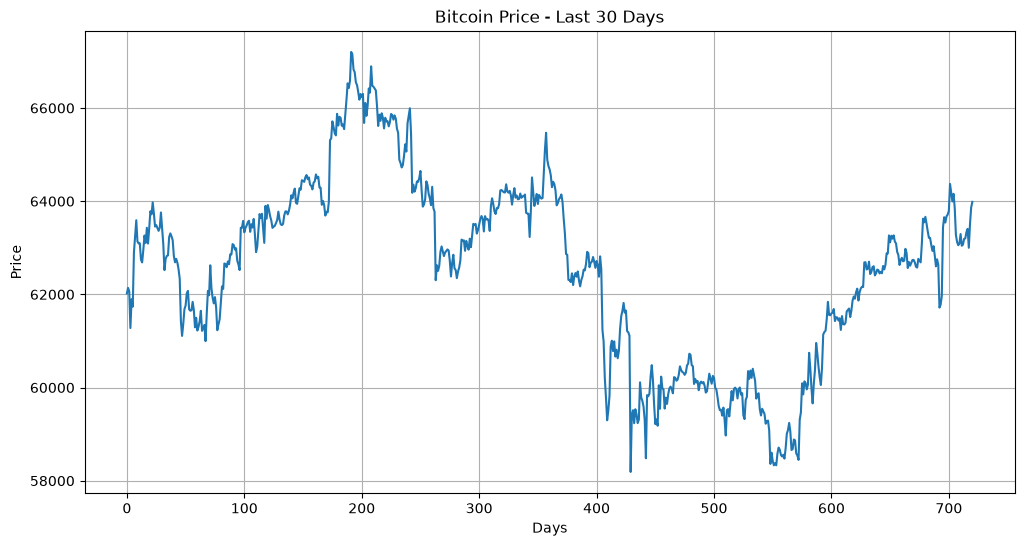

In [7]:
plt.figure(figsize=(12,6))

plt.plot(history["Price"])

plt.title("Bitcoin Price - Last 30 Days")

plt.xlabel("Days")

plt.ylabel("Price")

plt.grid(True)

plt.show()

In [8]:
df.to_csv("crypto_report.csv", index=False)

print("CSV Exported Successfully")

CSV Exported Successfully


In [9]:
coins = [
    "bitcoin",
    "ethereum",
    "solana",
    "dogecoin",
    "ripple",
    "cardano",
    "tron",
    "polkadot"
]

url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "ids": ",".join(coins)
}

response = requests.get(url, params=params)

df = pd.DataFrame(response.json())

print(df[[
    "name",
    "current_price",
    "price_change_percentage_24h"
]])

       name  current_price  price_change_percentage_24h
0   Bitcoin   63976.000000                      0.52107
1  Ethereum    1802.530000                      0.55877
2       XRP       1.130000                     -1.84583
3    Solana      82.150000                      0.22206
4      TRON       0.332122                      1.41667
5  Dogecoin       0.075351                     -2.03026
6   Cardano       0.177524                     -3.86326
7  Polkadot       0.872756                     -2.38904
